---
Auteurs:
  - Franck Deba Wandji
  - Durel Valdes Tchamou
  

---

# Méthodes des différences finies pour les put européens (Euler explicit/ implicite scheme)

## Objectif

---
L’objectif est de **calculer numériquement le prix d’un Put européen** en cherchant une fonction $ v(t, s) $ qui dépend du **temps**  $t$  et du **prix du sous-jacent**  $s$ . Cette fonction satisfait une **équation aux dérivées partielles (EDP)** (l’équation de **Black-Scholes**) qui traduit l’évolution du prix de l’option dans le temps.

---

## EDP de Black-Scholes


$$
\frac{\partial v}{\partial t} 
- \frac{\sigma^2}{2}s^2 \frac{\partial^2 v}{\partial s^2} 
- rs \frac{\partial v}{\partial s} 
+ rv = 0,
$$


définie sur le domaine  $\Omega = [S_{\text{min}}, S_{\text{max}}]$ .

- Conditions aux limites et condition initiale


$$
\begin{cases}
v(t, S_{\text{min}}) = Ke^{-rt} - S_{\text{min}}, & t \in (0, T),\\
v(t, S_{\text{max}}) = 0, & t \in (0, T),\\
v(0, s) = (K - s)^+, & s \in (S_{\text{min}}, S_{\text{max}}).
\end{cases}
$$

- Avec les paramètres suivants :
$K = 100, \quad S_{\text{min}} = 0, \quad S_{\text{max}} = 200, \quad \sigma = 0.2, \quad r = 0.1.$


## Discrétisation du domaine

On introduit un maillage en **espace** et en **temps** : $h = \frac{S_{\text{max}} - S_{\text{min}}}{J+1}, \quad \Delta t = \frac{T}{N}.$

Les points du maillage sont définis par : $s_j = S_{\text{min}} + jh, \quad j = 0, \dots, J+1,$ et $t_n = n\Delta t, \quad n = 0, \dots, N.$

On cherche alors une **approximation discrète** de la fonction de prix : $U^n_j \approx v(t_n, s_j).$


## Principe des méthodes de différences finies

L’idée est de remplacer les dérivées partielles de l’équation de Black-Scholes par des **approximations en différences finies**, selon différents schémas numériques :

- **Schéma explicite (Euler avant)**  
  Facile à implémenter mais conditionnellement stable.
  
- **Schéma implicite (Euler arrière)**  
  Plus stable mais nécessite la résolution d’un système linéaire à chaque étape de temps.
  
- **Schéma de Crank–Nicolson**  
  Moyenne des deux précédents, offrant une meilleure précision et stabilité.


### Schéma d'Euler Explicite (EE)
Dans un premier temps, on a recours au schéma d'euler explicite qui se décline comme suit : 

\begin{cases}
\frac{U^{n+1}_j - U^n_j}{\Delta t} + \frac{\sigma^2}{2} s_j^2 \frac{-U^n_{j-1} + 2U^n_j - U^n_{j+1}}{h^2} - r s_j \frac{U^n_{j+1} - U^n_{j-1}}{2h} + r U^n_j = 0  , \quad n = 0, \dots, N-1, \quad j = 1, \dots, J \\ 
U^n_0 = v_\ell(t_n) \equiv K e^{-r t_n} - S_{\text{min}}, \quad n = 0, \dots, N  \\
U^n_{J+1} = v_r(t_n) \equiv 0, \quad n = 0, \dots, N  \\
U^0_j = \phi(s_j) \equiv (K - s_j)^+, \quad j = 1, \dots, J 
\end{cases}

On oriente le travail avec une vision vectorielle $\ (v(t_n, s_j))_{j=1,\dots,J} \ $ :
$\
U^n =
\begin{pmatrix}
U^n_1 \\
\vdots \\
U^n_J
\end{pmatrix}.
\ $
Ce qui nous permet de réécrire le système d'équation précédent sous forme matricielle comme suit : 

\begin{cases}
    \frac{U^{n+1} - U^n}{\Delta t} + A U^n + q(t_n) = 0, \quad n = 0, \dots, N-1 \\
    U^0 = (\phi(s_j))_{1 \leq j \leq J}
\end{cases}

On pose $\alpha_j := \frac{\sigma^2}{2} \frac{s_j^2}{h^2}, \quad \beta_j := \frac{r s_j}{2h}. \ $ On cherche alors $\ A \ $ et $\ q(t) \ $ tels que : 

$\alpha_j(-U^n_{j-1} + 2U^n_j - U^n_{j+1}) - \beta_j(U^n_{j+1} - U^n_{j-1}) + r U^n_j
= (-\alpha_j + \beta_j)U^n_{j-1} + (2\alpha_j + r)U^n_j + (-\alpha_j - \beta_j)U^n_{j+1}
\equiv (AU + q(t_n))_j. \ $

Par identification, on a bien : 
$\
A :=
\begin{bmatrix}
2\alpha_1 + r & -\alpha_1 - \beta_1 & 0 & \cdots & 0 \\
-\alpha_2 + \beta_2 & 2\alpha_2 + r & -\alpha_2 - \beta_2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots & \vdots \\
0 & \cdots & -\alpha_J + \beta_J & 2\alpha_J + r
\end{bmatrix}.
\ $

Et $\ q(t_n) \ $ contient les valeurs aux bornes $\ U^n_0 = v_\ell(t_n) \ $ et $\ U^n_{J+1} = v_r(t_n) \ $ et est défini comme suit :

\begin{cases}
q(t_n) :=
\begin{pmatrix}
(-\alpha_1 + \beta_1)U^n_0 \\
0 \\
\vdots \\
0 \\
(-\alpha_J - \beta_J)U^n_{J+1}
\end{pmatrix}
\equiv
\begin{pmatrix}
(-\alpha_1 + \beta_1)v_\ell(t_n) \\
0 \\
\vdots \\
0 \\
(-\alpha_J - \beta_J)v_r(t_n)
\end{pmatrix}.
\end{cases}

Le code ci-dessous est une implémentation du schéma d'Euler explicite. 

### Schéma d'Euler Implicite (EI)
De ce qui précède on a vu que le schéma d'Euler explicite présente une instabilité numérique en fonction maillage considéré. On observe en effet, une explosion et des oscillations dans les résultats de ce schéma dû à la matrice d'amplification. On a constaté que l'instabilité pouvait être corrigée en considérant N et J tels que N soit proportionnel au carré de J. Toutefois, une telle approche est très coûteuse en termes d'itérations. Pour y rémédier on va donc implémenter le schéma d'Euler implicite qui est définit de façon récursive par les équations ci-après : 
$$
\begin{cases}
\frac{U^{n+1}_j - U^n_j}{\Delta t} + \frac{\sigma^2}{2} s_j^2 \frac{-U^{n+1}_{j-1} + 2U^{n+1}_j - U^{n+1}_{j+1}}{h^2} - r s_j \frac{U^{n+1}_{j+1} - U^{n+1}_{j-1}}{2h} + r U^{n+1}_j = 0  , \quad n = 0, \dots, N-1, \quad j = 1, \dots, J \\ 
U^{n+1}_0 = v_\ell(t_{n+1}) \equiv K e^{-r t_{n+1}} - S_{\text{min}}, \quad n = 0, \dots, N-1  \\
U^n_{I+1} = v_r(t_{n+1}) \equiv 0, \quad n = 0, \dots, N-1  \\
U^0_j = \phi(s_j) \equiv (K - s_j)^+, \quad j = 1, \dots, J 
\end{cases}
$$

On travaille avec le même vecteur inconnu $\ (v(t_n, s_j))_{j=1,\dots,J} \ $ :
$\
U^n =
\begin{pmatrix}
U^n_1 \\
\vdots \\
U^n_J
\end{pmatrix}.
\ $
On peut réécrire le système d'équation sous forme matricielle comme suit : 

\begin{cases}
\frac{U^{n+1} - U^n}{\Delta t} + A U^{n+1} + q(t_{n+1}) = 0, \quad n = 0, \dots, N-1 \\
U^0 = (\phi(s_i))_{1 \leq i \leq J}
\end{cases}

### Schéma de Crank-Nicolson (CN)
On a pu constater que le schéma d'Euler Implicite se comporte plutôt bien. Il est stable numériquement mais l'ordre du schéma se vérifie numériquement pour de grande valeur de N. A présent on s'intéresse au schéma de CRANK NICOLSON qui est définit de façon récursive par les équations ci-après : 

\begin{cases}
\frac{U^{n+1}_j - U^n_j}{\Delta t} + \frac{1}{2} (-\frac{\sigma^2}{2} s_j^2 \frac{U^{n+1}_{j-1} - 2U^{n+1}_j + U^{n+1}_{j+1}}{h^2} - r s_j \frac{U^{n+1}_{j+1} - U^{n+1}_{j-1}}{2h} + r U^{n+1}_j) + \frac{1}{2} (-\frac{\sigma^2}{2} s_j^2 \frac{U^{n}_{j-1} - 2U^{n}_j + U^{n}_{j+1}}{h^2} - r s_j \frac{U^{n}_{j+1} - U^{n}_{j-1}}{2h} + r U^{n}_j) = 0  , \quad n = 0, \dots, N-1, \quad j = 1, \dots, J \\ 
U^{n+1}_0 = v_\ell(t_{n+1}) \equiv K e^{-r t_{n+1}} - S_{\text{min}}, \quad n = 0, \dots, N-1  \\
U^n_{J+1} = v_r(t_{n+1}) \equiv 0, \quad n = 0, \dots, N-1  \\
U^0_j = \phi(s_j) \equiv (K - s_j)^+, \quad j = 1, \dots, J
\end{cases}

On travaille avec le même vecteur inconnu $\ (v(t_n, s_j))_{j=1,\dots,J} \ $ :
$\
U^n =
\begin{pmatrix}
U^n_1 \\
\vdots \\
U^n_J
\end{pmatrix}.
\ $
On peut réécrire le système d'équation sous forme matricielle comme suit : 

\begin{cases}
\frac{U^{n+1} - U^n}{\Delta t} + A (\frac{U^{n} + U^{n}}{2}) + q(t_{n+1}) + q(t_{n}) = 0, \quad n = 0, \dots, N-1 \\
U^0 = (\phi(s_i))_{1 \leq i \leq J}
\end{cases}

Et plus simplement

\begin{cases}
(A + \frac{2}{\Delta t})U^{n+1} = - (A - \frac{2}{\Delta t})U^{n+1} - (q(t_{n+1}) + q(t_{n})), \quad n = 0, \dots, N-1 \\
U^0 = (\phi(s_i))_{1 \leq i \leq J}
\end{cases}

## Programming Euler explicit/ implicite and Crank-Nicolson schemes

In [92]:
# Libraries utiles
import numpy as np
import matplotlib.pyplot as plt

from typing import List
import time 
from scipy.stats import norm
import pandas as pd


In [93]:
from abc import ABC, abstractmethod

"""
Module pour la résolution de l'EDP de Black-Scholes par différences finies.
Implémente les schémas Euler Explicite, Euler Implicite et Crank-Nicolson.
"""
class ConfigScheme:
    """Configuration des paramètres numériques."""
    
    def __init__(self, N: int, J: int, Smin: float, Smax: float, scheme: str):
        self.N = N          # Pas de temps
        self.J = J          # Points spatiaux
        self.Smin = Smin    # Borne inférieure
        self.Smax = Smax    # Borne supérieure
        self.scheme = scheme  # Type de schéma


class Scheme(ABC):
    """Solveur de l'équation de Black-Scholes pour un put européen."""
    def __init__(self, K: float, T: float, sigma: float, r: float, config: ConfigScheme):
        # Paramètres financiers
        self.K = K
        self.T = T
        self.sigma = sigma
        self.r = r
        
        # Configuration numérique
        self.config = config
        self.h = (config.Smax - config.Smin) / (config.J + 1)
        self.dt = T / config.N
        
        # Résultats
        self.s = None
        self.U = None
    
    def phi(self, s: np.array) -> np.array:
        """Payoff du put européen : max(K - s, 0)"""
        return np.maximum(self.K - s, 0).reshape(-1, 1)

    def uleft(self, t: float) -> float:
        """Condition limite à gauche (S = Smin)"""
        return self.K * np.exp(-self.r * t) - self.config.Smin

    def uright(self, t: float) -> float:
        """Condition limite à droite (S = Smax)"""
        return 0

    @abstractmethod
    def run(self):
        """Exécute le schéma numérique sélectionné."""
        pass

    def q(self, t: float, alpha: np.array, beta: np.array) -> np.array:
        """Terme source incluant les conditions limites"""
        q_vec = np.zeros((self.config.J, 1))
        q_vec[0, :] = (-alpha[0] + beta[0]) * self.uleft(t)
        q_vec[-1, :] = (-alpha[-1] - beta[-1]) * self.uright(t)
        return q_vec  

    def interpolate(self, sval: float) -> float:
        """Interpolation linéaire de la solution."""
        i = 0
        while i < len(self.s) - 1 and sval > self.s[i + 1]:
            i += 1
        if i >= len(self.s) - 1:
            return self.U[-1, 0]
        return ((self.s[i + 1] - sval) * self.U[i, 0] + (sval - self.s[i]) * self.U[i + 1, 0]) / self.h

    def plot(self):
        """Visualisation de la solution et du payoff."""
        s_plot = np.linspace(self.config.Smin, self.config.Smax, 500)
        payoff = self.phi(s_plot)
        
        plt.figure(figsize=(8, 4))
        plt.plot(s_plot, payoff, 'k--', label="Payoff", alpha=0.7)
        plt.plot(self.s, self.U, 'b-', label=f"{self.config.scheme}", linewidth=2)
        
        plt.title(f"Put Européen - T={self.T}, N={self.config.N}, J={self.config.J}")
        plt.xlabel("Prix du sous-jacent (S)")
        plt.ylabel("Prix de l'option")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [94]:
class SchemeEulerE(Scheme):
    def __init__(self, K: float, T: float, sigma: float, r: float, config: ConfigScheme):
        super().__init__(K, T, sigma, r, config)
    
    def run(self):
        """Exécute le schéma d'Euler Explicite."""
        # Points spatiaux et coefficients
        s = self.config.Smin + self.h * np.arange(1, self.config.J + 1)
        alpha = (self.sigma**2 * s**2) / (2 * self.h**2)
        beta = (self.r * s) / (2 * self.h)
        
        # Construction de la matrice A
        A = np.zeros((self.config.J, self.config.J))
        for j in range(self.config.J):
            A[j, j] = 2 * alpha[j] + self.r
            if j < self.config.J - 1:
                A[j, j + 1] = -alpha[j] - beta[j]
            if j > 0:
                A[j, j - 1] = -alpha[j] + beta[j]
        
        # Initialisation
        t = 0
        U = self.phi(s)
        
        # Schéma Euler Explicite
        for _ in range(self.config.N):
            t += self.dt
            U = U - self.dt * (A @ U + self.q(t, alpha, beta))
                    
        self.s = np.zeros(self.config.J + 2)
        self.s[0] = self.config.Smin
        self.s[1:self.config.J + 1] = s
        self.s[-1] = self.config.Smax

        # on rajoute les bords    
        self.U = np.zeros((self.config.J + 2, U.shape[1]))
        self.U[1:self.config.J + 1,:] = U
        self.U[0,:] = self.uleft(self.T)
        self.U[-1,:] = self.uright(self.T)

In [95]:
class SchemeEulerI(Scheme):
    def __init__(self, K: float, T: float, sigma: float, r: float, config: ConfigScheme):
        super().__init__(K, T, sigma, r, config)
    
    def run(self):
        """Exécute le schéma d'Euler Implicite."""
        # Points spatiaux et coefficients
        s = self.config.Smin + self.h * np.arange(1, self.config.J + 1)
        alpha = (self.sigma**2 * s**2) / (2 * self.h**2)
        beta = (self.r * s) / (2 * self.h)
        
        # Construction de la matrice A
        A = np.zeros((self.config.J, self.config.J))
        for j in range(self.config.J):
            A[j, j] = 2 * alpha[j] + self.r
            if j < self.config.J - 1:
                A[j, j + 1] = -alpha[j] - beta[j]
            if j > 0:
                A[j, j - 1] = -alpha[j] + beta[j]
        
        # Initialisation
        t = 0
        U = self.phi(s)
        
        # Schéma Euler Implicite
        A_IE = np.eye(self.config.J) / self.dt + A
        for _ in range(self.config.N):
            t += self.dt
            b = U / self.dt - self.q(t, alpha, beta)
            U = np.linalg.solve(A_IE, b)
                    
        self.s = np.zeros(self.config.J + 2)
        self.s[0] = self.config.Smin
        self.s[1:self.config.J + 1] = s
        self.s[-1] = self.config.Smax

        # on rajoute les bords    
        self.U = np.zeros((self.config.J + 2, U.shape[1]))
        self.U[1:self.config.J + 1,:] = U
        self.U[0,:] = self.uleft(self.T)
        self.U[-1,:] = self.uright(self.T)

In [96]:
class SchemeCN(Scheme):
    def __init__(self, K: float, T: float, sigma: float, r: float, config: ConfigScheme):
        super().__init__(K, T, sigma, r, config)
    
    def run(self):
        """Exécute le schéma de Crank-Nicolson."""
        # Points spatiaux et coefficients
        s = self.config.Smin + self.h * np.arange(1, self.config.J + 1)
        alpha = (self.sigma**2 * s**2) / (2 * self.h**2)
        beta = (self.r * s) / (2 * self.h)
        
        # Construction de la matrice A
        A = np.zeros((self.config.J, self.config.J))
        for j in range(self.config.J):
            A[j, j] = 2 * alpha[j] + self.r
            if j < self.config.J - 1:
                A[j, j + 1] = -alpha[j] - beta[j]
            if j > 0:
                A[j, j - 1] = -alpha[j] + beta[j]
        
        # Initialisation
        t = 0
        U = self.phi(s)
        
        # Schéma Euler Implicite
        A_plus = 2 * np.eye(self.config.J) / self.dt + A
        A_moins = 2 * np.eye(self.config.J) / self.dt - A
        for _ in range(self.config.N):
            t += self.dt
            b = A_moins @ U - (self.q(t, alpha, beta) + self.q(t - self.dt, alpha, beta))
            U = np.linalg.solve(A_plus, b)
                    
        self.s = np.zeros(self.config.J + 2)
        self.s[0] = self.config.Smin
        self.s[1:self.config.J + 1] = s
        self.s[-1] = self.config.Smax

        # on rajoute les bords    
        self.U = np.zeros((self.config.J + 2, U.shape[1]))
        self.U[1:self.config.J + 1,:] = U
        self.U[0,:] = self.uleft(self.T)
        self.U[-1,:] = self.uright(self.T)

## Programming Numerical Tests

In [97]:
"""
Module de tests numériques pour les schémas d'Euler explicite/implicite et Crank-Nicolson.
Ce module permet d'évaluer les propriétés numériques des schémas de différences finies.
"""

# Classe de configuration pour les tests numériques
class ConfigNumericalTest:
    """
    Stocke les paramètres de configuration pour les tests numériques.
    
    Attributes:
        Smin (float): Borne inférieure du domaine spatial
        Smax (float): Borne supérieure du domaine spatial  
        Sval (float): Point d'évaluation pour calculer l'erreur
        scheme (str): Type de schéma ("EE", "EI" ou "CN")
    """
    def __init__(self, Smin: float, Smax: float, Sval: float, scheme: str):
        self.Smin = Smin    # Minimum du prix du sous-jacent
        self.Smax = Smax    # Maximum du prix du sous-jacent
        self.Sval = Sval    # Prix où on évalue la solution
        self.scheme = scheme  # Schéma numérique à tester
        if self.scheme == "EE":
            self.schema = SchemeEulerE
        elif self.scheme == "EI":
            self.schema = SchemeEulerI
        elif self.scheme == "CN":
            self.schema = SchemeCN


# Classe principale pour exécuter les tests numériques
class NumericalTest:
    """
    Classe qui implémente une série de tests numériques pour évaluer
    les performances des schémas de différences finies.
    
    Attributes:
        configTest (ConfigNumericalTest): Configuration des tests
        K (float): Prix d'exercice de l'option (strike)
        T (float): Maturité en années
        sigma (float): Volatilité du sous-jacent
        r (float): Taux d'intérêt sans risque
    """
    
    def __init__(self, configTest: ConfigNumericalTest):
        self.configTest = configTest  # Configuration des tests
        
        # Paramètres financiers fixes pour tous les tests
        self.K = 100      # Prix d'exercice (strike)
        self.T = 1        # Temps à maturité (1 an)
        self.sigma = 0.2  # Volatilité (20%)
        self.r = 0.1      # Taux d'intérêt (10%)

        # Variables pour stocker les résultats des tests
        self.result_stability = None     # Résultats test stabilité
        self.result_amplification = None # Résultats matrice amplification (EE seulement)
        self.result_cfl = None           # Résultats condition CFL (EE seulement)
        self.result_numOrd = None        # Résultats ordre de convergence
    
    # 3.a. Test de stabilité numérique et positivité
    def numericalStabilityTest(self, N: int, J: List[int], N_equal_J: bool):
        """
        Teste la stabilité numérique et la positivité de la solution.
        
        Args:
            N (int): Nombre de pas de temps si N_equal_J=False
            J (List[int]): Liste des nombres de points spatiaux à tester
            N_equal_J (bool): Si True, N = J pour chaque test
                              Si False, N est fixe pour tous les tests
        
        Returns:
            Tuple[pd.DataFrame, List[EulerScheme]]: 
                - DataFrame avec les résultats
                - Liste des objets EulerScheme calculés
        """
        schemeRes = []  # Stocke les solveurs calculés
        results = {'N': [], 'J': [], 'norm of U^n': [], 'number of neg. Uj^n': []}
        
        for j in J:
            # Détermine N selon le mode choisi
            if N_equal_J:
                n = j  # N = J
            else:
                n = N  # N fixe
            
            # Configuration et exécution du schéma
            config = ConfigScheme(n, j, self.configTest.Smin, 
                                     self.configTest.Smax, self.configTest.scheme)
            schema = self.configTest.schema(self.K, self.T, self.sigma, self.r, config)
            schema.run()
            
            # Enregistrement des résultats
            results['N'].append(n)
            results['J'].append(j)
            results['norm of U^n'].append(np.linalg.norm(schema.U[:,0], 2))  # Norme L2
            results['number of neg. Uj^n'].append(np.sum(schema.U[:,0] < 0)) # Valeurs négatives
            schemeRes.append(schema)
        
        return pd.DataFrame(results), schemeRes

    # 3.b. Analyse de la matrice d'amplification (Euler Explicite seulement)
    def amplificationMatrix(self, N: int, J: int) -> dict:
        """
        Analyse la matrice d'amplification B = I - dt*A pour le schéma EE.
        
        Args:
            N (int): Nombre de pas de temps
            J (int): Nombre de points spatiaux
        
        Returns:
            dict: Dictionnaire avec les propriétés de la matrice B
        """
        dt = self.T / N  # Pas de temps
        h = (self.configTest.Smax - self.configTest.Smin) / (J + 1)  # Pas spatial

        # Construction de la matrice A de l'EDP discrétisée
        A = np.zeros((J, J))
        
        # Points spatiaux et coefficients
        s = self.configTest.Smin + h * np.arange(1, J + 1)
        alpha = (self.sigma**2 * s**2) / (2 * h**2)  # Coefficient diffusion
        beta = (self.r * s) / (2 * h)                # Coefficient convection

        # Remplissage de la matrice tridiagonale A
        for j in range(J):
            A[j, j] = 2 * alpha[j] + self.r  # Terme diagonal
            if j < J - 1:
                A[j, j+1] = -alpha[j] - beta[j]  # Sur-diagonale
            if j > 0:
                A[j, j-1] = -alpha[j] + beta[j]  # Sous-diagonale

        # Fonction pour le terme source avec conditions limites
        def q(t):
            q_vec = np.zeros((J, 1))
            q_vec[0,:] = (-alpha[0] + beta[0]) * self.uleft(t)    # Condition gauche
            q_vec[J-1,:] = (-alpha[J-1] - beta[J-1]) * self.uright(t)  # Condition droite
            return q_vec

        # Simulation EE pour vérifier
        U = self.phi(s)  # Condition initiale
        t = 0
        for n in range(N):
            t += dt
            U = U - dt * (A @ U + q(t))

        # Matrice d'amplification B = I - dt*A
        B = np.identity(J) - dt * A

        # Analyse des propriétés de B
        negative = np.sum(B < 0)                     # Coefficients négatifs
        negative_diag = np.sum(B.diagonal() < 0)     # Diagonale négative
        modulus = np.sum(np.abs(B) > 1)              # Coefficients > 1 en valeur absolue
        modulus_diag = np.sum(np.abs(B.diagonal()) > 1)  # Diagonale > 1
        
        # Normes de la matrice
        norm_inf = np.linalg.norm(B, np.inf)  # Norme infinie
        norm_2 = np.linalg.norm(B, 2)         # Norme spectrale

        return {
            'N': N, 'J': J,
            'num neg. coef': negative,
            'num |coef| > 1': modulus,
            'num neg. diag. coef': negative_diag,
            'num diag. |coef| > 1': modulus_diag,
            'norm inf': norm_inf,
            'norm 2': norm_2
        }

    # 3.c. Fonctions utilitaires et condition CFL
    def phi(self, s: np.array) -> np.array:
        """Payoff du put européen : max(K - s, 0)"""
        return np.maximum(self.K - s, 0).reshape(-1, 1)
    
    def uleft(self, t: float) -> float:
        """Condition limite à gauche (S = Smin)"""
        return self.K * np.exp(-self.r * t) - self.configTest.Smin

    def uright(self, t: float) -> float:
        """Condition limite à droite (S = Smax)"""
        return 0

    def CFL(self, N: int, J: int) -> dict:
        """
        Calcule la condition CFL pour Euler Explicite.
        
        CFL = dt * sigma² * Smax**2 / h**2
        Cette condition doit être <= 1 pour la stabilité de EE.
        """
        h = (self.configTest.Smax - self.configTest.Smin) / (J + 1)  # Pas spatial
        dt = self.T / N  # Pas temporel
        cfl = dt * self.sigma**2 * self.configTest.Smax**2 / h**2
        return {'N': N, 'J': J, 'CFL': cfl}
    
    # 3.d. Solution analytique Black-Scholes  
    def v(self, t: float, S: float) -> float:
        """
        Solution exacte du put européen par la formule de Black-Scholes.
        
        Args:
            t (float): Temps restant jusqu'à maturité
            S (float): Prix actuel du sous-jacent
        
        Returns:
            float: Prix théorique du put européen
        """
        d_plus = (np.log(S / self.K) + (self.r + 0.5 * self.sigma**2) * t) / (self.sigma * np.sqrt(t))
        d_moins = d_plus - self.sigma * np.sqrt(t)
        return (-S * norm.cdf(-d_plus) + self.K * np.exp(-self.r * t) * norm.cdf(-d_moins))

    # 3.e. Calcul de l'ordre de convergence
    def numericalOrder(self, limit: int, N_equal_J: bool) -> pd.DataFrame:
        """
        Calcule l'ordre de convergence numérique du schéma.
        
        Args:
            limit (int): Nombre de raffinement (k dans 2^k)
            N_equal_J (bool): 
                True: N = J (raffinement uniforme)
                False: N = J^2 (respect condition CFL pour EE)
        
        Returns:
            pd.DataFrame: Tableau avec les résultats de convergence
        """
        results = {
            'J': [], 'N': [], 'U(s)': [],      # Paramètres et solution
            'error': [], 'alpha': [],           # Erreur et ordre
            'errex': [], 'tcpu': []             # Erreur exacte et temps CPU
        }
        h_list = []  # Liste des pas spatiaux

        for k in range(limit):
            # Choix du raffinement selon le mode
            if N_equal_J:
                N = 10 * 2**k
                J = N  # Raffinement uniforme
            else:
                if self.configTest.scheme == "EE":
                    N, J = 10 * (2**k)**2, 10 * 2**k  # N = J^2 / 10 pour respecter CFL
                else:
                    N, J = 2**k, 10 * 2**k  # N = J / 10
            
            # Mesure du temps de calcul
            start = time.perf_counter()
            
            # Configuration et exécution
            config = ConfigScheme(N, J, self.configTest.Smin, 
                                     self.configTest.Smax, self.configTest.scheme)
            schema = self.configTest.schema(self.K, self.T, self.sigma, self.r, config)
            schema.run()
            
            end = time.perf_counter()
            
            # Récupération des données
            s = schema.s      # Points spatiaux
            U = schema.U      # Solution numérique
            h = schema.h      # Pas spatial
            h_list.append(h)
            
            # Interpolation linéaire au point Sval
            U_init = schema.phi(s)  # Solution initiale (payoff)
            i = 0
            while self.configTest.Sval > s[i+1]:
                i += 1
            # Interpolation entre s[i] et s[i+1]
            U_s = ((s[i+1] - self.configTest.Sval) * U[i, 0] + 
                   (self.configTest.Sval - s[i]) * U[i+1, 0]) / h
            U_0 = ((s[i+1] - self.configTest.Sval) * U_init[i, 0] + 
                   (self.configTest.Sval - s[i]) * U_init[i+1, 0]) / h

            # Enregistrement des résultats
            results['J'].append(J)
            results['N'].append(N)
            results['U(s)'].append(U_s)
            results['errex'].append(abs(U_s - self.v(self.T, self.configTest.Sval)))  # Erreur vs BS
            results['tcpu'].append(end - start)  # Temps CPU
            
            # Calcul de l'ordre de convergence
            if k > 0:
                # Erreur entre solutions successives
                results['error'].append(abs(results['U(s)'][k-1] - results['U(s)'][k]))
                # Ordre alpha = log(erreur_k-1 / erreur_k) / log(h_k-1 / h_k)
                results['alpha'].append(
                    np.log(results['error'][k-1] / results['error'][k]) / 
                    np.log(h_list[k-1] / h_list[k])
                )
            else:
                # Premier raffinement : pas d'ordre à calculer
                results['error'].append(abs(U_0 - results['U(s)'][k]))
                results['alpha'].append(0.0)
        
        return pd.DataFrame(results)

    # Méthode principale pour exécuter tous les tests
    def runTest(self):
        """
        Exécute la suite complète des tests numériques.
        Stocke les résultats dans les attributs de la classe.
        """

        # 3.a. Test de stabilité - Deux scénarios
        # Scénario 1: N fixe = 10, J variable
        result_stability1, schemeRes1 = self.numericalStabilityTest(
            N=10, J=[10, 20, 50, 100], N_equal_J=False
        )
        # Scénario 2: N = J (raffinement uniforme)
        result_stability2, schemeRes2 = self.numericalStabilityTest(
            N=10, J=[10, 20, 50, 100], N_equal_J=True
        )
        # Fusion des résultats
        self.result_stability = [result_stability1, result_stability2]
        
        # Visualisation des résultats
        self.plot(schemeRes1, num_img=1)  # Premier scénario
        self.plot(schemeRes2, num_img=2)  # Deuxième scénario

        # Tests spécifiques au schéma Euler Explicite
        if self.configTest.scheme == "EE":
            # 3.b. Matrice d'amplification
            result_amplification = pd.DataFrame([self.amplificationMatrix(N=10, J=50)])
            result_amplification = pd.concat([result_amplification, 
                                            pd.DataFrame([self.amplificationMatrix(N=10, J=10)])])
            self.result_amplification = result_amplification.copy()

            # 3.c. Condition CFL
            result_cfl = pd.DataFrame([self.CFL(N=10, J=50)])
            result_cfl = pd.concat([result_cfl, 
                                  pd.DataFrame([self.CFL(N=10, J=10)])])
            self.result_cfl = result_cfl.copy()

        # 3.d. & 3.e. Ordre de convergence
        # Deux modes : raffinement uniforme et respect CFL
        result_numOrd = self.numericalOrder(7, N_equal_J=True)   # N = J
        result_numOrd = [result_numOrd, 
                                 self.numericalOrder(7, N_equal_J=False)]  # N = J^2
        self.result_numOrd = result_numOrd.copy()
        
        # Affichage des résultats
        self._print()

    def _print(self):
        """Affiche les résultats des tests de manière formatée."""
        print("----" * 4, f"{self.configTest.scheme}_scheme", "----" * 4)
        print("====" * 16)
        print("Numerical Stability (Scénario 1: N fixe = 10, J variable): \n", self.result_stability[0], "\n")
        print("----" * 16)
        print("Numerical Stability (Scénario 2: N = J): \n", self.result_stability[1], "\n")
        print("====" * 16)
        print("Amplification Matrix: \n", self.result_amplification, "\n")
        print("====" * 16)
        print("CFL: \n", self.result_cfl, "\n")
        print("====" * 16)
        print("Numerical Order (Scénario 1: N = J): \n", self.result_numOrd[0], "\n")
        print("----" * 16)
        if self.configTest.scheme == "EE":
            print("Numerical Order (Scénario 2: N = J^2 / 10): \n", self.result_numOrd[1], "\n")
        else:
            print("Numerical Order (Scénario 2: N = J / 10): \n", self.result_numOrd[1], "\n")
        print("====" * 16)

    def plot(self, schemeRes: List[Scheme], num_img: int): 
        """
        Affiche les solutions pour différents raffinements.
        
        Args:
            schemeRes (List[Scheme]): Liste des solveurs calculés
            num_img (int): Numéro de la figure (1 ou 2)
        """
        # Création de la figure avec 4 sous-graphiques (2x2)
        fig, axs = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle(f'Graphique {num_img}', fontsize=16)
        
        # Parcours des 4 solveurs
        for j, schema in enumerate(schemeRes):
            row, col = divmod(j, 2)  # Position dans la grille 2x2
            
            # Payoff théorique
            S = np.linspace(self.configTest.Smin, self.configTest.Smax, 500)
            payoff_values = self.phi(S)
            axs[row, col].plot(S, payoff_values, label=r'Payoff', 
                             color='black', linestyle='--')
            
            # Solution numérique
            axs[row, col].plot(schema.s, schema.U, 
                             label=f"{self.configTest.scheme}_Scheme "
                                   f"(N={schema.config.N}, J={schema.config.J})", 
                             color='blue')
            
            # Configuration du sous-graphique
            axs[row, col].set_title(f'N={schema.config.N}, J={schema.config.J}')
            axs[row, col].grid(alpha=0.5)
            axs[row, col].legend()
            axs[row, col].set_xlabel('Valeur du sous-jacent (s)')
            axs[row, col].set_ylabel('Prix du Put europeen')
        
        # Ajustement de la mise en page
        plt.tight_layout(rect=[0, 0, 1, 0.95])  # Espace pour le titre
        plt.show()

## Résultats numériques

In [98]:
# Paramètres du schéma
Smin = 0 # left truncated domain
Smax = 200 # right truncated domain
Sval = 80
J = 20
N = 20

# Paramètres de l'option
K = 100 # Strike
T = 1 # Maturity
sigma = 0.2 # Volatility
r = 0.1 # Interest rate

### Schéma d'Euleur Explicite

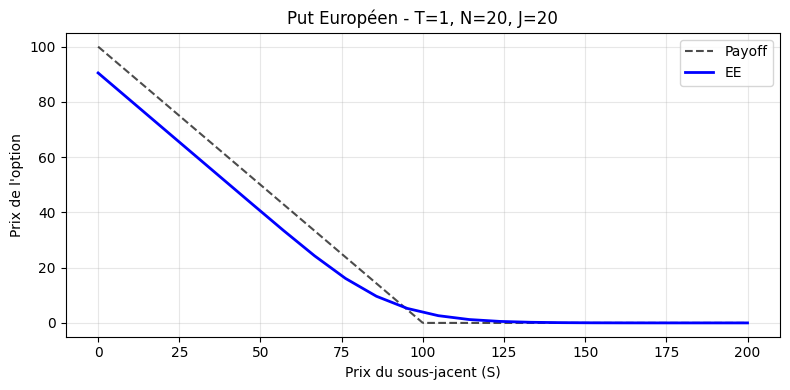

In [99]:
config = ConfigScheme(N, J, Smin, Smax, "EE")
schema_explicit = SchemeEulerE(K, T, sigma, r, config)
schema_explicit.run()
schema_explicit.plot()

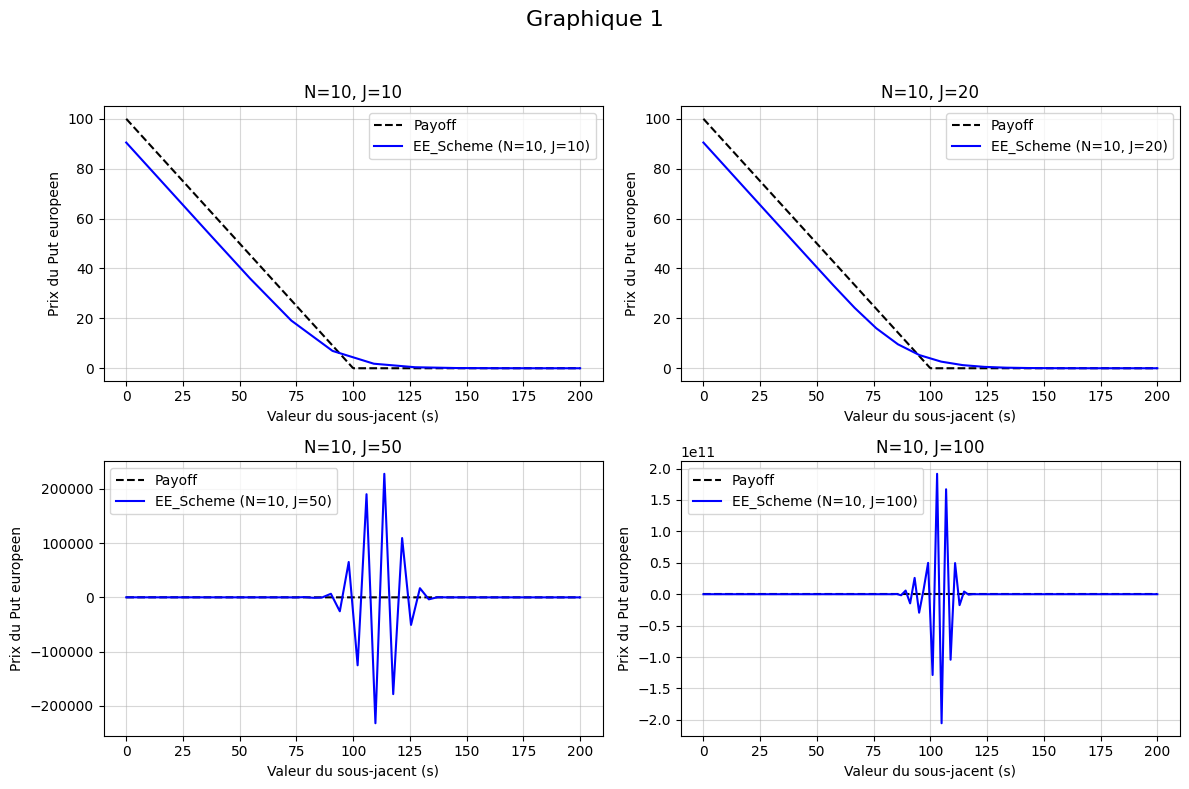

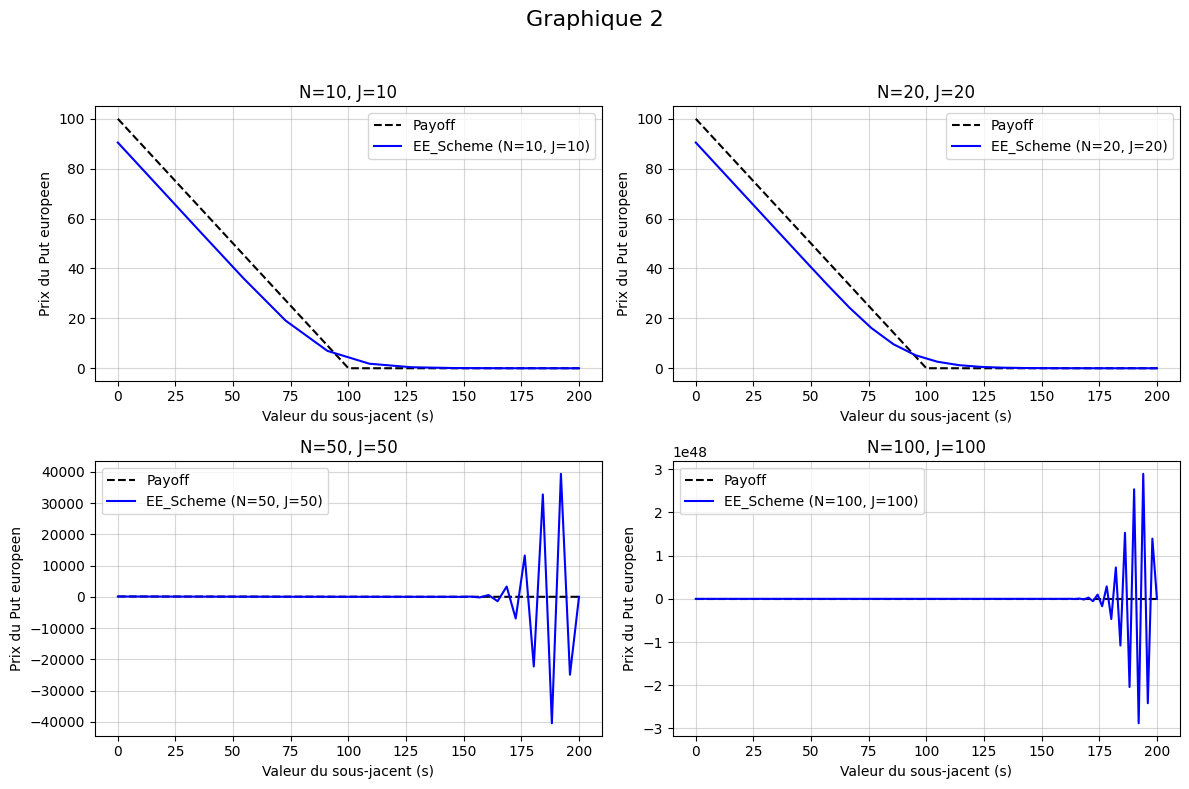

<positron-console-cell-100>:28: RuntimeWarning: overflow encountered in matmul
<positron-console-cell-100>:28: RuntimeWarning: invalid value encountered in matmul


---------------- EE_scheme ----------------
Numerical Stability (Scénario 1: N fixe = 10, J variable): 
     N    J   norm of U^n  number of neg. Uj^n
0  10   10  1.343541e+02                    0
1  10   20  1.741257e+02                    0
2  10   50  4.568989e+05                    9
3  10  100  3.760528e+11                    9 

----------------------------------------------------------------
Numerical Stability (Scénario 2: N = J): 
      N    J   norm of U^n  number of neg. Uj^n
0   10   10  1.343541e+02                    0
1   20   20  1.741898e+02                    0
2   50   50  7.494425e+04                    8
3  100  100  6.276881e+48                   37 

Amplification Matrix: 
     N   J  num neg. coef  num |coef| > 1  num neg. diag. coef  \
0  10  50             36              83                   35   
0  10  10              1               0                    0   

   num diag. |coef| > 1  norm inf     norm 2  
0                    28    18.218  16.473976  
0   

In [100]:
# Numerical Test for EI
configTest = ConfigNumericalTest(Smin, Smax, Sval, "EE")
schema_explicit_test = NumericalTest(configTest)
schema_explicit_test.runTest()

Les graphiques 1 et 2 mettent en évidence l’instabilité numérique du schéma d’Euler explicite. En effet, après un nombre fini d’itérations, on observe une explosion de la norme du vecteur des approximations $\ U^n \ $. Par ailleurs, certaines composantes 
$\ U^n_j \ $, qui approchent la solution $\ v(t_n, s_j) \ $, prennent des valeurs négatives, ce qui est indésirable au regard des propriétés attendues de la solution.

L’analyse du graphique 1 montre que, lorsque le nombre de pas de temps est faible (c’est-à-dire pour une petite valeur de N), l’augmentation du nombre de points du maillage spatial ($J$) conduit rapidement à une instabilité du schéma. Le graphique 2 confirme que cette instabilité persiste lorsque N et J augmentent simultanément et restent du même ordre de grandeur. Cette observation est cohérente à la violation de la condition CFL.

Ces observations suggèrent que, lorsque le maillage spatial est raffiné, il est nécessaire d’augmenter significativement le nombre de pas de temps pour préserver la stabilité numérique. Le schéma d’Euler explicite apparaît ainsi fortement contraint par le pas de temps et requiert un maillage temporel suffisamment fin pour garantir un comportement stable.

Afin de comprendre l'origine des oscillations et des explosions observées, on va s'intéresser à la matrice d'amplification définie comme suit  : $B := I_d - \Delta tA $. On sait que le schéma d'Euler peut être programmé en utilisant l'équation récursive ci-après : $U^{n+1} = U^n - \Delta t (A U^n + q(t_n)) $. Cette équation se réécrit : $U^{n+1} = (I_d - \Delta tA)U^n + \Delta tq(t_n) = BU^n + \Delta tq(t_n) $. De fait, toute oscillation ou explosion dans les approximations provient de la matrice $B$.

Somme toute, le schéma d'Euler Explicite (EE) présente un comportement conditionnellement stable, entièrement dicté par le respect de la condition CFL. 
- Pour N=10, J=10 (CFL=0.484 < 1), la solution reste stable avec une norme $L^2$ de 134.35. 
- En revanche, pour J=50 (CFL=10.404 >> 1), on observe une instabilité explosive : la norme atteint $3.76 \times 10^{11}$ avec apparition de 9 valeurs négatives (contre-intuitif vu la positivité de la fonction de prix).
- La matrice $B = I - \Delta t A$ du schéma EE montre présente :
    - Pour J=10 : aucune valeur propre de module > 1, norme 2 de B vaut  0.987 < 1.
    - Pour J=50 : 83 coefficients de modules > 1, norme 2 de B vaut 16.474 >> 1.
Ces résultats corroborent parfaitement la condition de stabilité de von Neumann : la stabilité nécessite $\rho(B) \leq 1$.
- Consernant la convergence du schéma,
    - Le cas N = J est problématique dès lors qu'il ne satisfait pas la condition CFL. En effet, pour J=40 l'ordre de convergence $\alpha = 1.99$ traduisant une convergence. Mais, pour des ordres plus grand le schéma diverge drastiquement. Par exemple avec J=80 $\alpha = -16.02$. Cette divergence est conforme aux analyses théoriques.
    - Dans le cas $N = J^2 / 10$, l'ordre asymptotique se stabilise autour de $\alpha = 1.97$, proche de l'ordre théorique 2.

### Schéma d'Euler Implicit

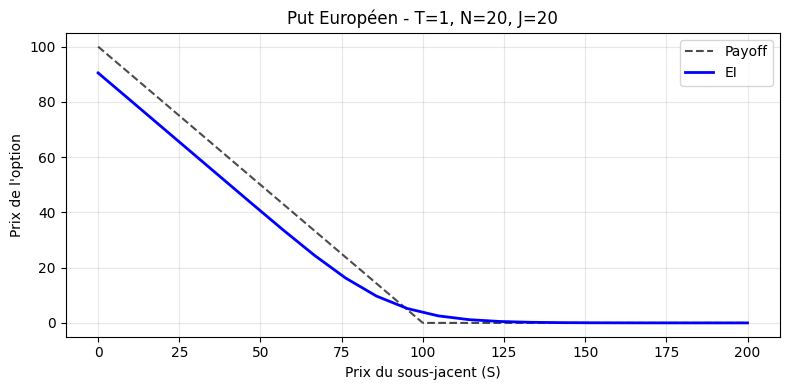

In [101]:
config = ConfigScheme(N, J, Smin, Smax, "EI")
schema_implicit = SchemeEulerI(K, T, sigma, r, config)
schema_implicit.run()
schema_implicit.plot()

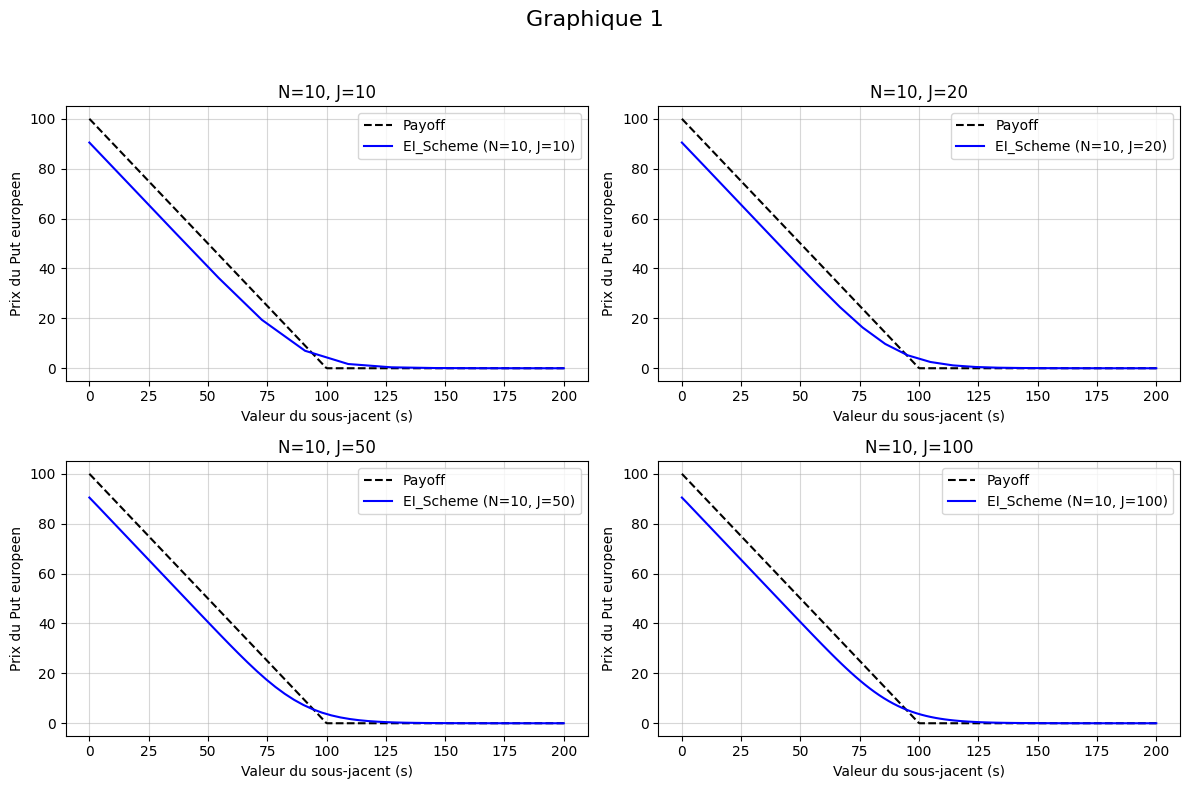

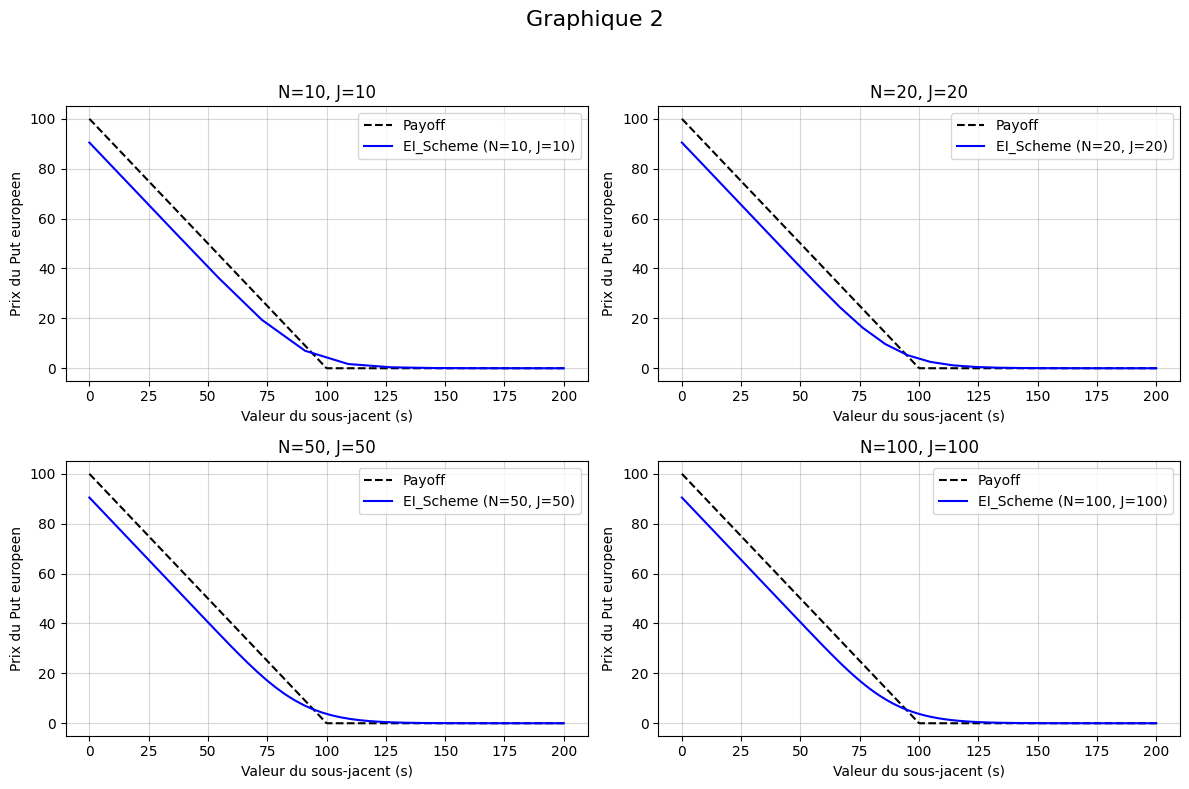

---------------- EI_scheme ----------------
Numerical Stability (Scénario 1: N fixe = 10, J variable): 
     N    J  norm of U^n  number of neg. Uj^n
0  10   10   134.513874                    0
1  10   20   174.391789                    0
2  10   50   260.194029                    0
3  10  100   360.513178                    0 

----------------------------------------------------------------
Numerical Stability (Scénario 2: N = J): 
      N    J  norm of U^n  number of neg. Uj^n
0   10   10   134.513874                    0
1   20   20   174.322877                    0
2   50   50   260.005281                    0
3  100  100   360.204581                    0 

Amplification Matrix: 
 None 

CFL: 
 None 

Numerical Order (Scénario 1: N = J): 
      J    N       U(s)     error     alpha     errex      tcpu
0   10   10  14.448406  5.551594  0.000000  1.174743  0.000354
1   20   20  13.642159  0.806247  2.983868  0.368496  0.000645
2   40   40  13.386145  0.256015  1.714605  0.112482  0

In [102]:
# Numerical Test for EI
configTest = ConfigNumericalTest(Smin, Smax, Sval, "EI")
schema_explicit_test = NumericalTest(configTest)
schema_explicit_test.runTest()

- Les graphiques ci-dessus permettent de constater que le schéma d'Euler implicite ne pose aucun problème de stabilité. En effet, on observe aucune oscillation ou explosion. Le schéma semble bien approcher le payoff du Put européen.
- Les tableaux des ordres de convergence montrent que le schéma d'Euler implicite est stable numériquement. Aussi les résultats du premier suggère qu'il n'est pas nécessaire des valeurs de N proportionnelles au carré de J pour assurer la stabilité du schéma. 
- Les erreurs de convergence et l'erreur exacte sont du même ordre.
- Des colonnes alpha des deux tableaux on peut voir que l'ordre du schéma implicite converge vers 1, conformément aux attentes théoriques.


### Crank-Nicolson scheme

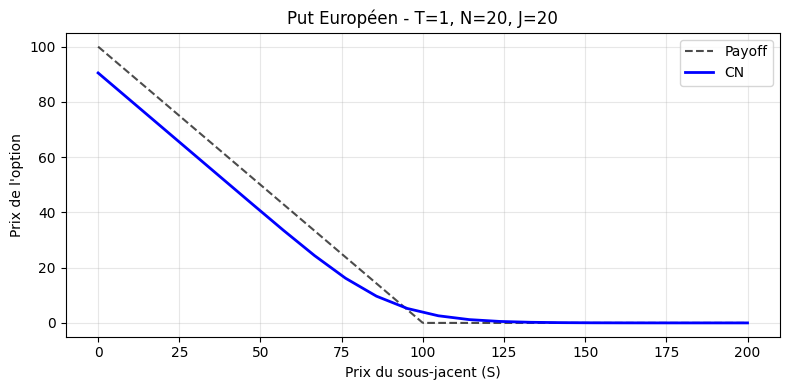

In [103]:
config = ConfigScheme(N, J, Smin, Smax, "CN")
schema_CN = SchemeCN(K, T, sigma, r, config)
schema_CN.run()
schema_CN.plot()

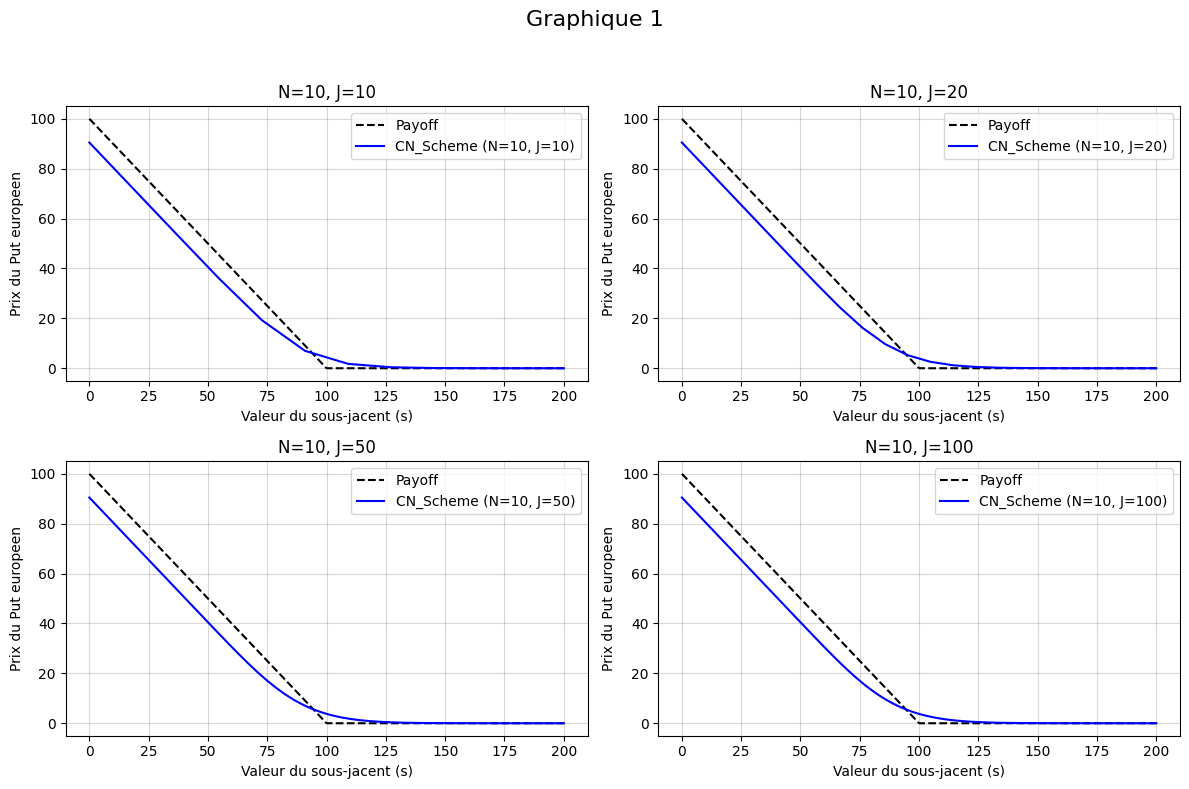

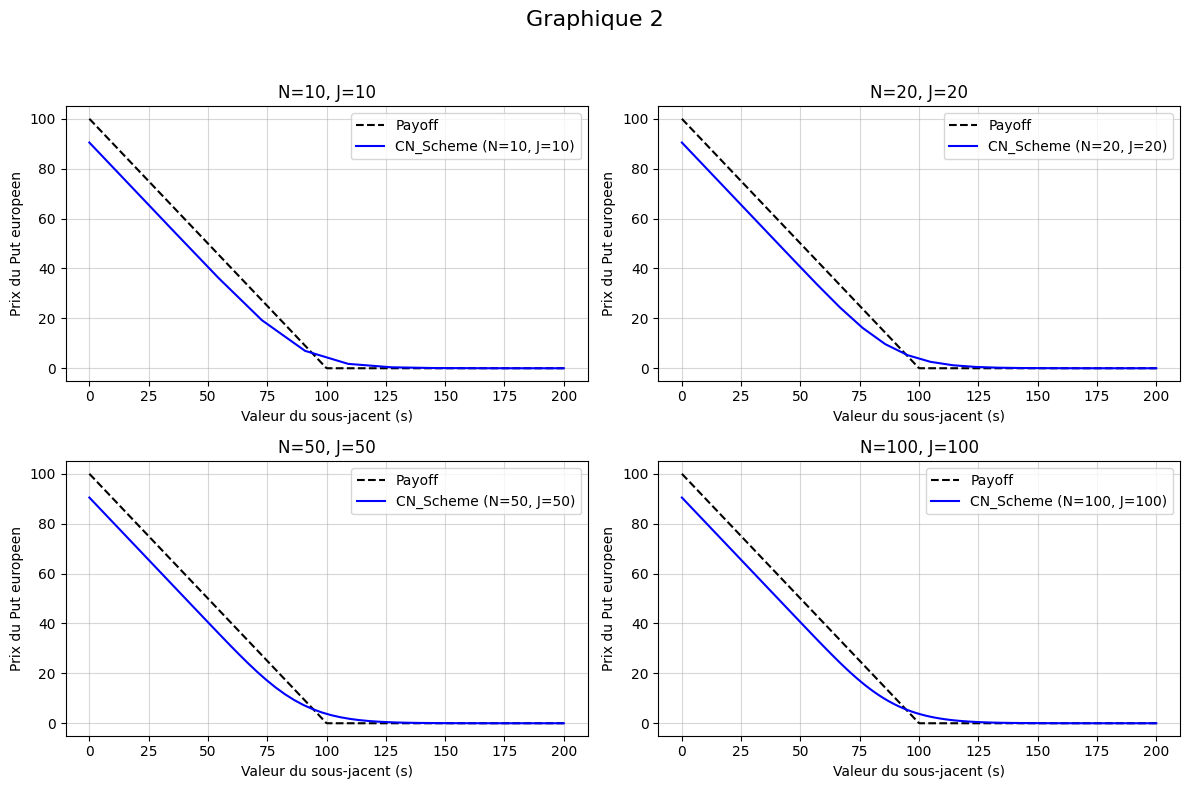

---------------- CN_scheme ----------------
Numerical Stability (Scénario 1: N fixe = 10, J variable): 
     N    J  norm of U^n  number of neg. Uj^n
0  10   10   134.427249                    0
1  10   20   174.253196                    0
2  10   50   259.957269                    0
3  10  100   360.169332                    0 

----------------------------------------------------------------
Numerical Stability (Scénario 2: N = J): 
      N    J  norm of U^n  number of neg. Uj^n
0   10   10   134.427249                    0
1   20   20   174.253419                    0
2   50   50   259.957749                    0
3  100  100   360.170048                    0 

Amplification Matrix: 
 None 

CFL: 
 None 

Numerical Order (Scénario 1: N = J): 
      J    N       U(s)     error     alpha     errex      tcpu
0   10   10  14.353451  5.646549  0.000000  1.079788  0.000448
1   20   20  13.578892  0.774559  3.072104  0.305229  0.000546
2   40   40  13.353140  0.225752  1.842696  0.079477  0

In [104]:
# Numerical Test for EI
configTest = ConfigNumericalTest(Smin, Smax, Sval, "CN")
schema_CN_test = NumericalTest(configTest)
schema_CN_test.runTest()

- Comme pour le schéma implicite, le schéma de Crank-Nicolson est numériquement stable tel que l'illustre les graphiques ci-dessus.
- En outre, la colonne des alpha montre une converge monotone de l'ordre du schéma vers 2 lorsque N=J. Cette convergence n'est cependant pas monotone lorsque $N=J/10$.
- Comparé au schéma implicite d'Euler, les colonnes des erreurs montrent que la convergence du schéma CN est eponentiellement plus fine pour les niveaux de maillage.

### Version Sparse du schema de Crank-Nicolson

In [105]:
from scipy.sparse import csr_matrix as sparse
from scipy.sparse.linalg import spsolve

class SchemeCN(Scheme):
    """SVersion sparse du schema de Crank-Nicolson"""
    def __init__(self, K: float, T: float, sigma: float, r: float, config: ConfigScheme):
        super().__init__(K, T, sigma, r, config)

    def run(self):
        """Exécute le schéma numérique sélectionné."""
        # Points spatiaux et coefficients
        s = self.config.Smin + self.h * np.arange(1, self.config.J + 1)
        alpha = (self.sigma**2 * s**2) / (2 * self.h**2)
        beta = (self.r * s) / (2 * self.h)
        
        # Construction de la matrice A
        A = np.zeros((self.config.J, self.config.J))
        for j in range(self.config.J):
            A[j, j] = 2 * alpha[j] + self.r
            if j < self.config.J - 1:
                A[j, j + 1] = -alpha[j] - beta[j]
            if j > 0:
                A[j, j - 1] = -alpha[j] + beta[j]
        
        # Initialisation
        t = 0
        U = self.phi(s)
    
        # Setting the CN (Crank-Nicolson) scheme
        A_CN_plus = 2 / self.dt * np.identity(self.config.J) + A
        A_CN_moins = (2 / self.dt * np.identity(self.config.J) - A)
        for n in range(self.config.N):
            t += self.dt
            b = A_CN_moins @ U[:,:] - (self.q(t + self.dt, alpha, beta) + self.q(t, alpha, beta))
            U = spsolve(A_CN_plus, b).reshape(-1, 1)
        
        self.s = np.zeros(self.config.J + 2)
        self.s[0] = self.config.Smin
        self.s[1:self.config.J + 1] = s
        self.s[-1] = self.config.Smax

        # on rajoute les bords    
        self.U = np.zeros((self.config.J + 2, U.shape[1]))
        self.U[1:self.config.J + 1,:] = U
        self.U[0,:] = self.uleft(self.T)
        self.U[-1,:] = self.uright(self.T)      

<positron-console-cell-106>:35: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format


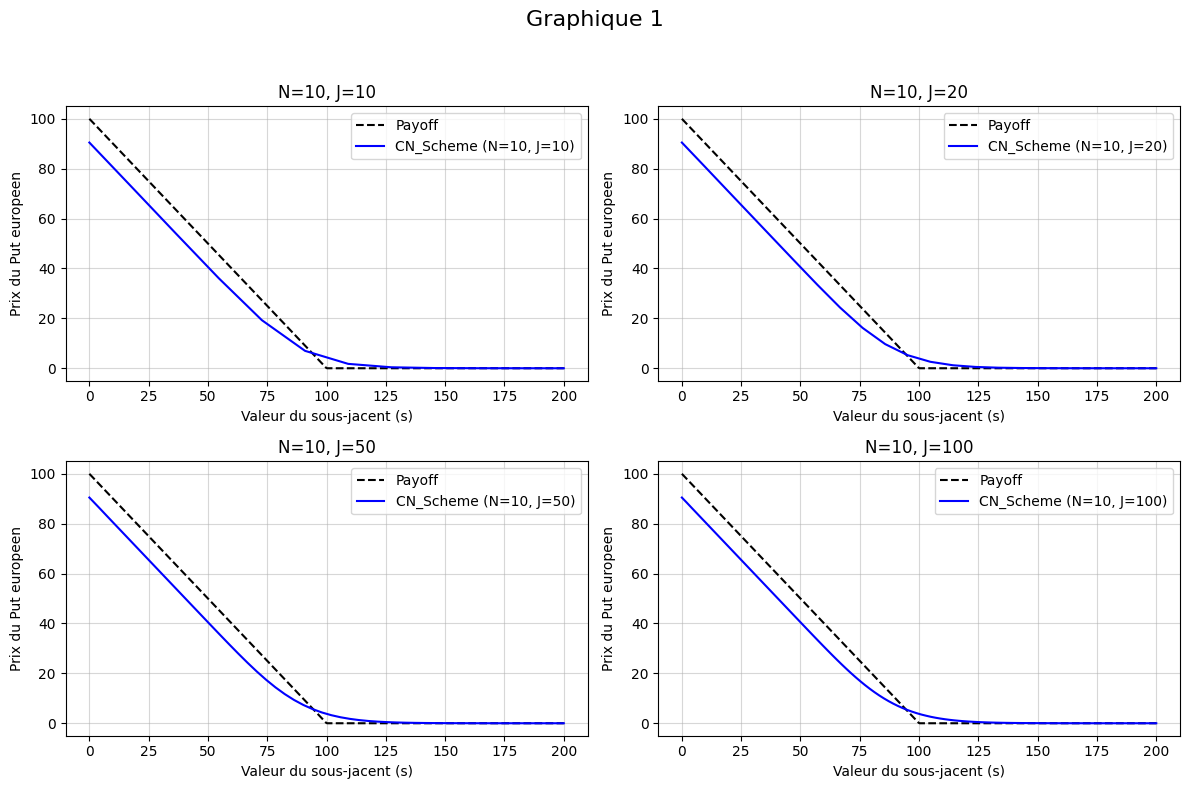

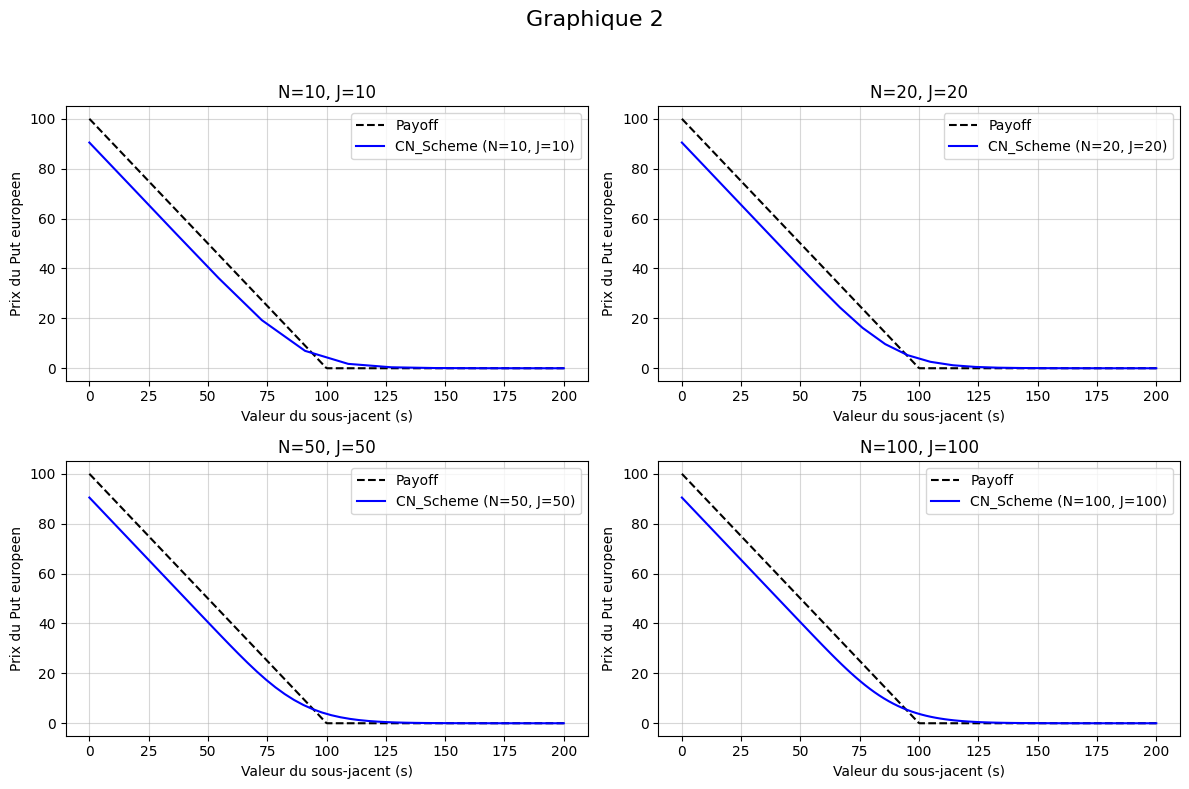

---------------- CN_scheme ----------------
Numerical Stability (Scénario 1: N fixe = 10, J variable): 
     N    J  norm of U^n  number of neg. Uj^n
0  10   10   134.441387                    0
1  10   20   174.265392                    0
2  10   50   259.966003                    0
3  10  100   360.175776                    0 

----------------------------------------------------------------
Numerical Stability (Scénario 2: N = J): 
      N    J  norm of U^n  number of neg. Uj^n
0   10   10   134.441387                    0
1   20   20   174.259532                    0
2   50   50   259.959503                    0
3  100  100   360.170695                    0 

Amplification Matrix: 
 None 

CFL: 
 None 

Numerical Order (Scénario 1: N = J): 
      J    N       U(s)     error     alpha     errex      tcpu
0   10   10  14.353451  5.646549  0.000000  1.079788  0.004824
1   20   20  13.578892  0.774559  3.072104  0.305229  0.005635
2   40   40  13.353140  0.225752  1.842696  0.079477  0

In [106]:
# Numerical Test for CN
configTest = ConfigNumericalTest(Smin, Smax, Sval, "CN")
schema_CN_sparse = NumericalTest(configTest)
schema_CN_sparse .runTest()

En comparant les tableaux des ordres numériques sur la colonne du temps computationnel au cas précédent, on constate que le schéma de Crank-Nicolson est environ 2 fois plus rapide (on passe de 5.65 secondes à 2.56 secondes, avec N=J=640). Ainsi, en utilisant une matrice A est creuse, on a un véritable gain dans le temps d'éxécution pour de grandes valeurs de N et de J.

# Finite difference method for a European call option (Euler explicit/ implicite scheme)

---
L'objectif de cette section est de résoudre numériquement l'équation d'un call européen.
Le prix du call européen est solution de l'EDP ci-après :

\begin{cases}
\frac{\partial v}{\partial t} - \frac{\sigma^2}{2} s^2 \frac{\partial^2 v}{\partial s^2} - rs \frac{\partial v}{\partial s} + rv = 0, & t \in (0, T), s \in (S_{\text{min}}, S_{\text{max}}), \\
v(t, S_{\text{min}}) = v_\ell(t) \equiv 0, & t \in (0, T), \\
v(t, S_{\text{max}}) = v_r(t) \equiv S_{\text{max}} - K e^{-r(T-t)}, & t \in (0, T), \\
v(0, s) = \phi(s) := \max(s - K, 0), & s \in (S_{\text{min}}, S_{\text{max}}).
\end{cases}

On va implémenter et tester dans la suite le schéma d'Euler implicite dans le cas du call européen en s'inspirant des implémentaions déjà faite pour le put. 

---

In [107]:
"""
Module pour la résolution de l'EDP de Black-Scholes par différences finies.
Implémente les schémas Euler Explicite, Euler Implicite et Crank-Nicolson.
"""

class CallSchemeEulerI(SchemeEulerI):
    """Solveur de l'équation de Black-Scholes pour un call européen."""
    
    def phi(self, s: np.array) -> np.array:
        """Payoff Function"""
        return np.maximum(s - self.K, 0).reshape(-1,1)

    def uleft(self, t: float) -> float:
        """Left boundary function"""
        return 0

    def uright(self, t: float) -> float:
        """Right boundary function"""
        return self.config.Smax - self.K * np.exp(- self.r * t)

    def plot(self):
        """Visualisation de la solution et du payoff."""
        s_plot = np.linspace(self.config.Smin, self.config.Smax, 500)
        payoff = self.phi(s_plot)
        
        plt.figure(figsize=(8, 4))
        plt.plot(s_plot, payoff, 'k--', label="Payoff", alpha=0.7)
        plt.plot(self.s, self.U, 'b-', label=f"{self.config.scheme}", linewidth=2)
        
        plt.title(f"Call Européen - T={self.T}, N={self.config.N}, J={self.config.J}")
        plt.xlabel("Prix du sous-jacent (S)")
        plt.ylabel("Prix de l'option")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

In [108]:
"""
Module de tests numériques pour les schémas d'Euler explicite/implicite et Crank-Nicolson.
Ce module permet d'évaluer les propriétés numériques des schémas de différences finies.
"""
class ConfigNumericalTestCall:
    """
    Stocke les paramètres de configuration pour les tests numériques.
    
    Attributes:
        Smin (float): Borne inférieure du domaine spatial
        Smax (float): Borne supérieure du domaine spatial  
        Sval (float): Point d'évaluation pour calculer l'erreur
        scheme (str): Type de schéma ("EE", "EI" ou "CN")
    """
    def __init__(self, Smin: float, Smax: float, Sval: float, scheme: str):
        self.Smin = Smin    # Minimum du prix du sous-jacent
        self.Smax = Smax    # Maximum du prix du sous-jacent
        self.Sval = Sval    # Prix où on évalue la solution
        self.scheme = scheme  # Schéma numérique à tester
        self.schema = CallSchemeEulerI
        

# Classe principale pour exécuter les tests numériques
class NumericalTestCall(NumericalTest):
     # 3.c. Fonctions utilitaires et condition CFL
    def phi(self, s: np.array) -> np.array:
        """Payoff Function"""
        return np.maximum(s - self.K, 0).reshape(-1,1)

    def uleft(self, t: float) -> float:
        """Left boundary function"""
        return 0

    def uright(self, t: float) -> float:
        """Right boundary function"""
        return self.config.Smax - self.K * np.exp(- self.r * t)
    
    # 3.d. Solution analytique Black-Scholes  
    def v(self, t: float, S: float) -> float:
        """
        Solution exacte du put européen par la formule de Black-Scholes.
        
        Args:
            t (float): Temps restant jusqu'à maturité
            S (float): Prix actuel du sous-jacent
        
        Returns:
            float: Prix théorique du put européen
        """
        d_plus = (np.log(S / self.K) + (self.r + 0.5 * self.sigma**2) * t) / (self.sigma * np.sqrt(t))
        d_moins = d_plus - self.sigma * np.sqrt(t)
        return (S * norm.cdf(d_plus) - self.K * np.exp(-self.r * t) * norm.cdf(d_moins))

    def plot(self, schemeRes: List[Scheme], num_img: int): 
        """
        Affiche les solutions pour différents raffinements.
        
        Args:
            schemeRes (List[EulerSchemeCall]): Liste des solveurs calculés
            num_img (int): Numéro de la figure (1 ou 2)
        """
        # Création de la figure avec 4 sous-graphiques (2x2)
        fig, axs = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle(f'Graphique {num_img}', fontsize=16)
        
        # Parcours des 4 solveurs
        for j, euler_scheme in enumerate(schemeRes):
            row, col = divmod(j, 2)  # Position dans la grille 2x2
            
            # Payoff théorique
            S = np.linspace(self.configTest.Smin, self.configTest.Smax, 500)
            payoff_values = self.phi(S)
            axs[row, col].plot(S, payoff_values, label=r'Payoff', 
                             color='black', linestyle='--')
            
            # Solution numérique
            axs[row, col].plot(euler_scheme.s, euler_scheme.U, 
                             label=f"{self.configTest.scheme}_Scheme "
                                   f"(N={euler_scheme.config.N}, J={euler_scheme.config.J})", 
                             color='blue')
            
            # Configuration du sous-graphique
            axs[row, col].set_title(f'N={euler_scheme.config.N}, J={euler_scheme.config.J}')
            axs[row, col].grid(alpha=0.5)
            axs[row, col].legend()
            axs[row, col].set_xlabel('Valeur du sous-jacent (s)')
            axs[row, col].set_ylabel('Prix du Put europeen')
        
        # Ajustement de la mise en page
        plt.tight_layout(rect=[0, 0, 1, 0.95])  # Espace pour le titre
        plt.show()

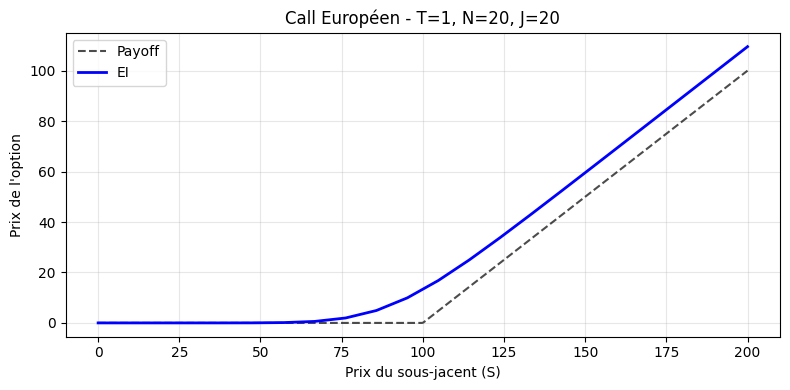

In [109]:
config = ConfigScheme(N, J, Smin, Smax, "EI")
schema_explicit = CallSchemeEulerI(K, T, sigma, r, config)
schema_explicit.run()
schema_explicit.plot()

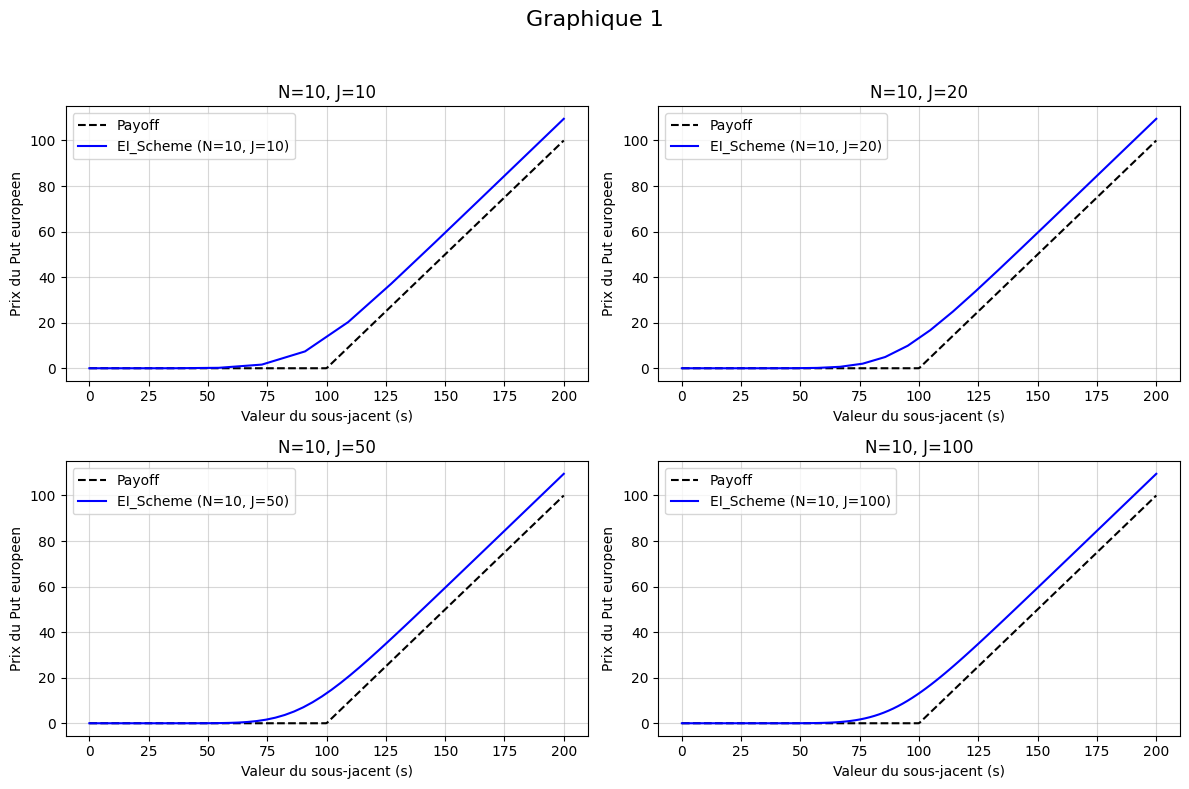

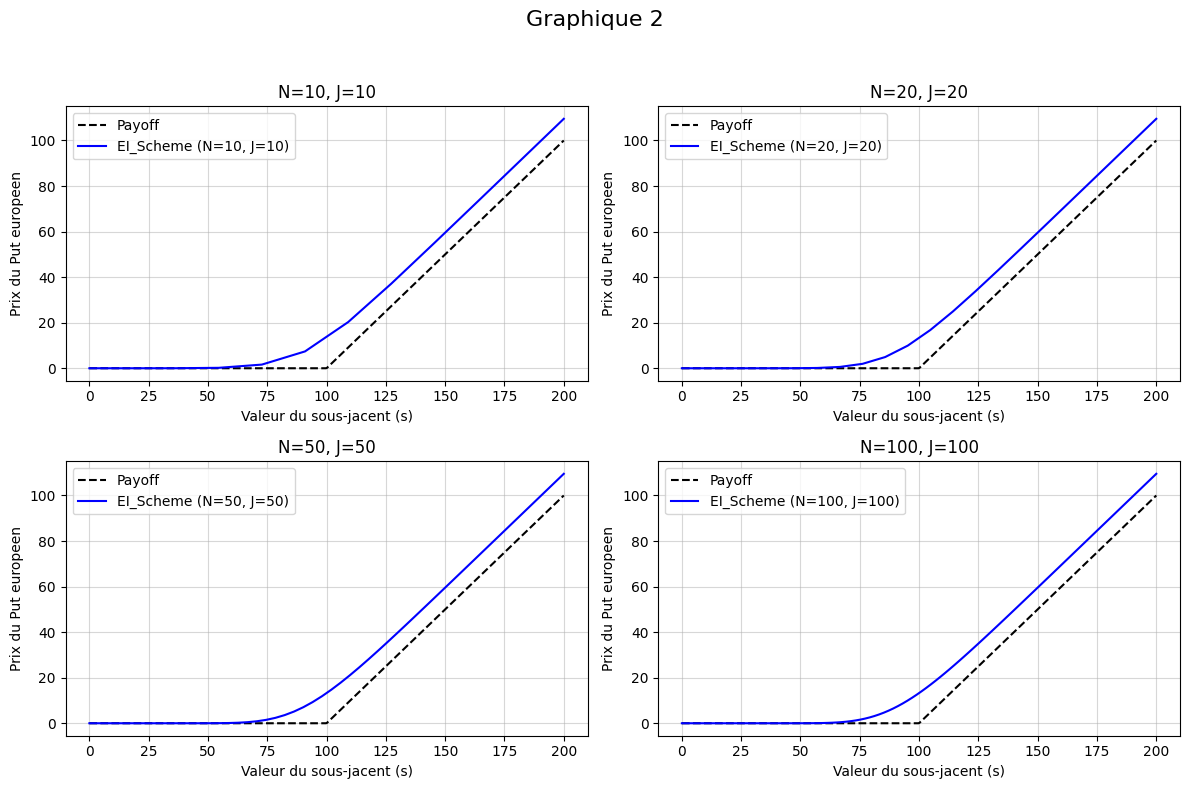

---------------- EI_scheme ----------------
Numerical Stability (Scénario 1: N fixe = 10, J variable): 
     N    J  norm of U^n  number of neg. Uj^n
0  10   10   174.800166                    0
1  10   20   228.953495                    0
2  10   50   344.072016                    0
3  10  100   477.979355                    0 

----------------------------------------------------------------
Numerical Stability (Scénario 2: N = J): 
      N    J  norm of U^n  number of neg. Uj^n
0   10   10   174.800166                    0
1   20   20   228.998121                    0
2   50   50   344.189133                    0
3  100  100   478.167798                    0 

Amplification Matrix: 
 None 

CFL: 
 None 

Numerical Order (Scénario 1: N = J): 
      J    N      U(s)     error     alpha     errex      tcpu
0   10   10  3.919729  3.919729  0.000000  1.129808  0.000369
1   20   20  3.135870  0.783859  2.489145  0.345949  0.000668
2   40   40  2.891111  0.244759  1.739711  0.101189  0.001

In [110]:
# Numerical test for EE
configTest = ConfigNumericalTestCall(Smin, Smax, Sval, "EI")
schema_explicit_test = NumericalTestCall(configTest)
schema_explicit_test.runTest()

On remarque que les observation numériques faites dans le cas d'un put restent valables dans le cas du call. La seule différence entre les deux implémentaion réside en le fait que nous ayons choisi d'utiliser un solveur sparse pour le schéma implicite. Ce choix s'inscrit dans les conclusion d'optimisation computationnel pour les matrices creuses.